<a href="https://colab.research.google.com/github/AnanyaAsthana/Data-Mining-Warehousing-Lab/blob/main/dmw_lab_1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# Synthetic Superstore Dataset Generator
# Suitable for Q1 - Q11
# ==========================================

import numpy as np
import pandas as pd

np.random.seed(42)

# -------------------------
# Number of records
# -------------------------
N = 1500

# -------------------------
# Categories
# -------------------------
categories = {
    "Furniture": [
        "Bookcases",
        "Chairs",
        "Tables",
        "Furnishings"
    ],
    "Office Supplies": [
        "Binders",
        "Paper",
        "Storage",
        "Appliances",
        "Art",
        "Envelopes",
        "Fasteners"
    ],
    "Technology": [
        "Phones",
        "Accessories",
        "Machines",
        "Copiers",
        "Labels",
        "Supplies"
    ]
}

regions = ["East", "West", "Central", "South"]

category_list = []
subcategory_list = []

for i in range(N):
    cat = np.random.choice(
        list(categories.keys()),
        p=[0.30, 0.45, 0.25]
    )

    sub = np.random.choice(categories[cat])

    category_list.append(cat)
    subcategory_list.append(sub)

region = np.random.choice(
    regions,
    N,
    p=[0.27,0.28,0.23,0.22]
)

# -------------------------
# Sales
# Right-skewed distribution
# -------------------------
sales = np.random.lognormal(
    mean=4.3,
    sigma=0.9,
    size=N
)

sales = np.round(sales,2)

# -------------------------
# Quantity
# -------------------------
quantity = np.random.randint(
    1,
    11,
    size=N
)

# -------------------------
# Discount
# -------------------------
discount_levels = [0,0.1,0.2,0.3,0.4,0.5]

discount = np.random.choice(
    discount_levels,
    size=N,
    p=[0.30,0.20,0.20,0.15,0.10,0.05]
)

# -------------------------
# Category Profit Margin
# -------------------------
margin = []

for c in category_list:

    if c=="Technology":
        margin.append(0.30)

    elif c=="Office Supplies":
        margin.append(0.18)

    else:
        margin.append(0.12)

margin = np.array(margin)

# -------------------------
# Regional Effect
# -------------------------
region_bonus = []

for r in region:

    if r=="West":
        region_bonus.append(15)

    elif r=="East":
        region_bonus.append(10)

    elif r=="Central":
        region_bonus.append(0)

    else:
        region_bonus.append(-5)

region_bonus = np.array(region_bonus)

# -------------------------
# Profit
# -------------------------
noise = np.random.normal(0,40,N)

profit = (
    sales*margin
    - sales*discount*0.85
    + region_bonus
    + noise
)

profit = np.round(profit,2)

# -------------------------
# Create DataFrame
# -------------------------
df = pd.DataFrame({

    "Sales":sales,
    "Quantity":quantity,
    "Discount":discount,
    "Profit":profit,
    "Region":region,
    "Category":category_list,
    "Sub_Category":subcategory_list

})

# -------------------------
# Shuffle rows
# -------------------------
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# -------------------------
# Save CSV
# -------------------------
df.to_csv("synthetic_superstore.csv",index=False)

print(df.head())

print("\nShape:",df.shape)

print("\nSaved as synthetic_superstore.csv")

    Sales  Quantity  Discount  Profit   Region         Category Sub_Category
0   49.92         2       0.2  -23.84    South       Technology       Labels
1   93.30         2       0.0   31.25     East       Technology     Supplies
2   67.88         1       0.2 -103.96    South        Furniture       Chairs
3  406.49         9       0.0  163.14     West  Office Supplies   Appliances
4   53.46         4       0.2  -74.91  Central        Furniture    Bookcases

Shape: (1500, 7)

Saved as synthetic_superstore.csv


Five-Number Summary (Profit)
Minimum : -295.35
Q1      : -20.73
Median  : 9.57
Q3      : 41.29
Maximum : 172.28

IQR = 62.02

Lower Bound = -113.75
Upper Bound = 134.32

Number of Outliers = 14


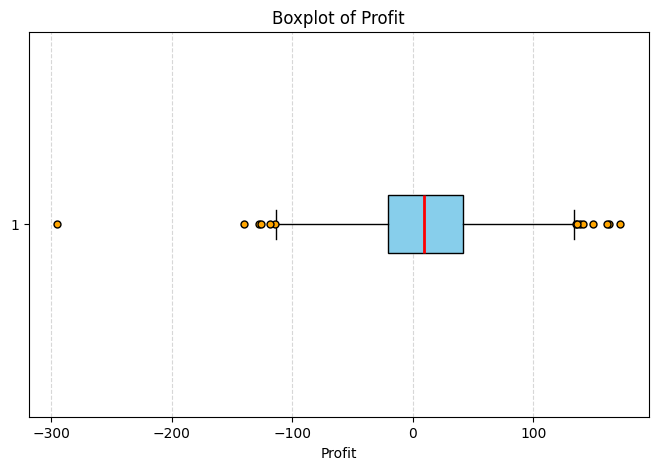

In [ ]:
# ==========================================
# Q1: Boxplot & Five-Number Summary
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("synthetic_superstore.csv")

# -----------------------------
# Five-Number Summary
# -----------------------------
minimum = df["Profit"].min()
q1 = df["Profit"].quantile(0.25)
median = df["Profit"].median()
q3 = df["Profit"].quantile(0.75)
maximum = df["Profit"].max()

# -----------------------------
# IQR
# -----------------------------
iqr = q3 - q1

# -----------------------------
# Outlier Limits
# -----------------------------
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

# -----------------------------
# Detect Outliers
# -----------------------------
outliers = df[
    (df["Profit"] < lower_limit) |
    (df["Profit"] > upper_limit)
]

# -----------------------------
# Print Results
# -----------------------------
print("="*50)
print("Five-Number Summary (Profit)")
print("="*50)

print(f"Minimum : {minimum:.2f}")
print(f"Q1      : {q1:.2f}")
print(f"Median  : {median:.2f}")
print(f"Q3      : {q3:.2f}")
print(f"Maximum : {maximum:.2f}")

print("\nIQR =", round(iqr,2))

print("\nLower Bound =", round(lower_limit,2))
print("Upper Bound =", round(upper_limit,2))

print("\nNumber of Outliers =", len(outliers))

# -----------------------------
# Boxplot
# -----------------------------
plt.figure(figsize=(8,5))

plt.boxplot(
    df["Profit"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="skyblue"),
    medianprops=dict(color="red", linewidth=2),
    flierprops=dict(marker='o',
                    markerfacecolor='orange',
                    markersize=5)
)

plt.title("Boxplot of Profit")
plt.xlabel("Profit")
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

Sales Bin with Largest Profit Spread : S5
Quantity Bin : Q1
Largest IQR : 89.55


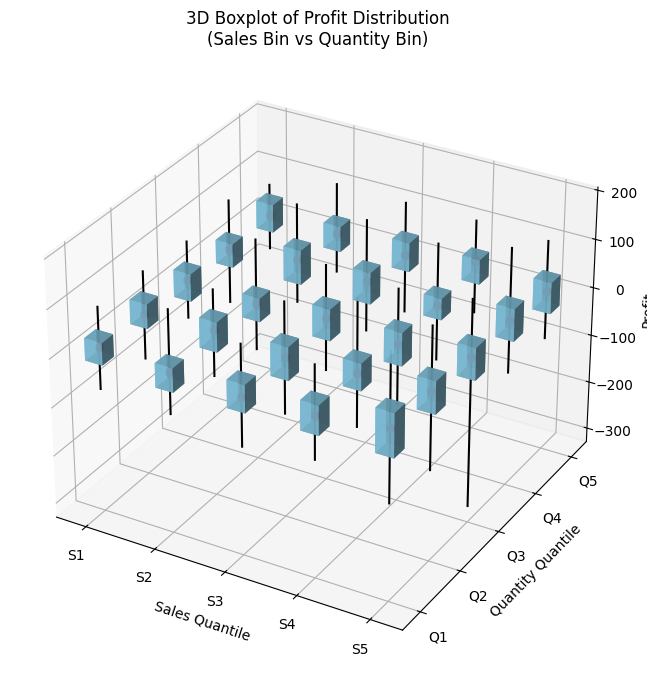

In [ ]:
# ==========================================
# Q2: 3D Boxplot (Sales Bin vs Quantity Bin)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load dataset
df = pd.read_csv("synthetic_superstore.csv")

# ----------------------------------
# Create Equal-Frequency Bins
# ----------------------------------
df["Sales_Bin"] = pd.qcut(df["Sales"], q=5, labels=["S1","S2","S3","S4","S5"])
df["Quantity_Bin"] = pd.qcut(df["Quantity"], q=5, labels=["Q1","Q2","Q3","Q4","Q5"])

# ----------------------------------
# Compute Statistics
# ----------------------------------
stats = []

sales_labels = ["S1","S2","S3","S4","S5"]
quantity_labels = ["Q1","Q2","Q3","Q4","Q5"]

for i, s in enumerate(sales_labels):
    for j, q in enumerate(quantity_labels):

        profits = df[
            (df["Sales_Bin"] == s) &
            (df["Quantity_Bin"] == q)
        ]["Profit"]

        if len(profits) == 0:
            continue

        q1 = profits.quantile(0.25)
        median = profits.median()
        q3 = profits.quantile(0.75)
        iqr = q3 - q1
        low = profits.min()
        high = profits.max()

        stats.append([
            i, j,
            low, q1,
            median,
            q3,
            high,
            iqr
        ])

stats = pd.DataFrame(stats, columns=[
    "x","y",
    "Min","Q1",
    "Median",
    "Q3",
    "Max",
    "IQR"
])

# ----------------------------------
# Largest IQR
# ----------------------------------
largest = stats.loc[stats["IQR"].idxmax()]

print("="*60)
print("Sales Bin with Largest Profit Spread :", sales_labels[int(largest["x"])])
print("Quantity Bin :", quantity_labels[int(largest["y"])])
print("Largest IQR :", round(largest["IQR"],2))
print("="*60)

# ----------------------------------
# 3D Boxplot Style Visualization
# ----------------------------------
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

box_width = 0.25

for _, row in stats.iterrows():

    x = row["x"]
    y = row["y"]

    # Whisker
    ax.plot(
        [x,x],
        [y,y],
        [row["Min"], row["Max"]],
        color="black",
        linewidth=1.5
    )

    # IQR Box
    ax.bar3d(
        x-box_width/2,
        y-box_width/2,
        row["Q1"],
        box_width,
        box_width,
        row["Q3"]-row["Q1"],
        color="skyblue",
        alpha=0.8
    )

    # Median
    ax.scatter(
        x,
        y,
        row["Median"],
        color="red",
        s=35
    )

ax.set_xticks(range(5))
ax.set_xticklabels(sales_labels)

ax.set_yticks(range(5))
ax.set_yticklabels(quantity_labels)

ax.set_xlabel("Sales Quantile")
ax.set_ylabel("Quantity Quantile")
ax.set_zlabel("Profit")

ax.set_title("3D Boxplot of Profit Distribution\n(Sales Bin vs Quantity Bin)")

plt.show()

Skewness of Sales = 3.627
Distribution: Right-Skewed


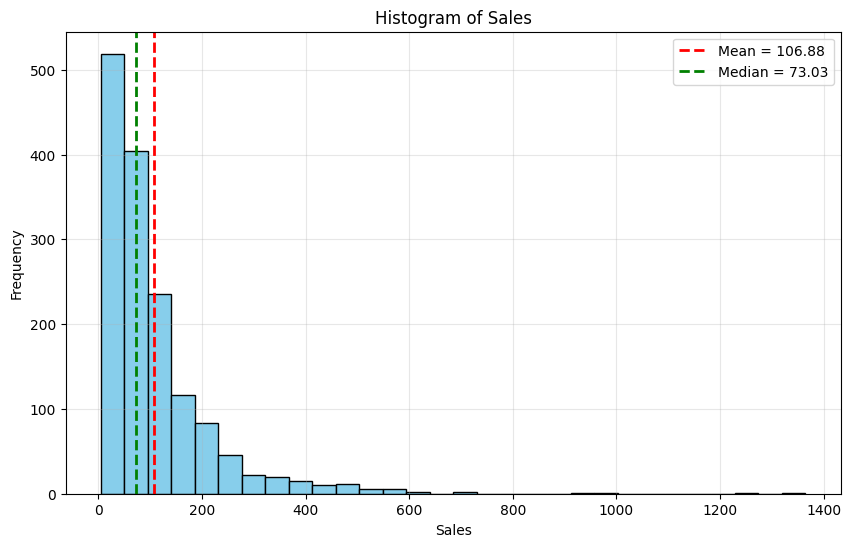

In [ ]:
# ==========================================
# Q3: Histogram & Skewness of Sales
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("synthetic_superstore.csv")

# ----------------------------------
# Calculate Skewness
# ----------------------------------
skewness = df["Sales"].skew()

print("="*50)
print("Skewness of Sales =", round(skewness, 3))

if skewness > 0.5:
    print("Distribution: Right-Skewed")
elif skewness < -0.5:
    print("Distribution: Left-Skewed")
else:
    print("Distribution: Approximately Symmetric")
print("="*50)

# ----------------------------------
# Histogram
# ----------------------------------
plt.figure(figsize=(10,6))

plt.hist(
    df["Sales"],
    bins=30,
    color="skyblue",
    edgecolor="black"
)

# Mean and Median
mean_sales = df["Sales"].mean()
median_sales = df["Sales"].median()

plt.axvline(mean_sales, color="red", linestyle="--",
            linewidth=2, label=f"Mean = {mean_sales:.2f}")

plt.axvline(median_sales, color="green", linestyle="--",
            linewidth=2, label=f"Median = {median_sales:.2f}")

plt.title("Histogram of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Median Sales (f = 0.5): 73.03
Percentage of Transactions with Sales < $100: 64.07%


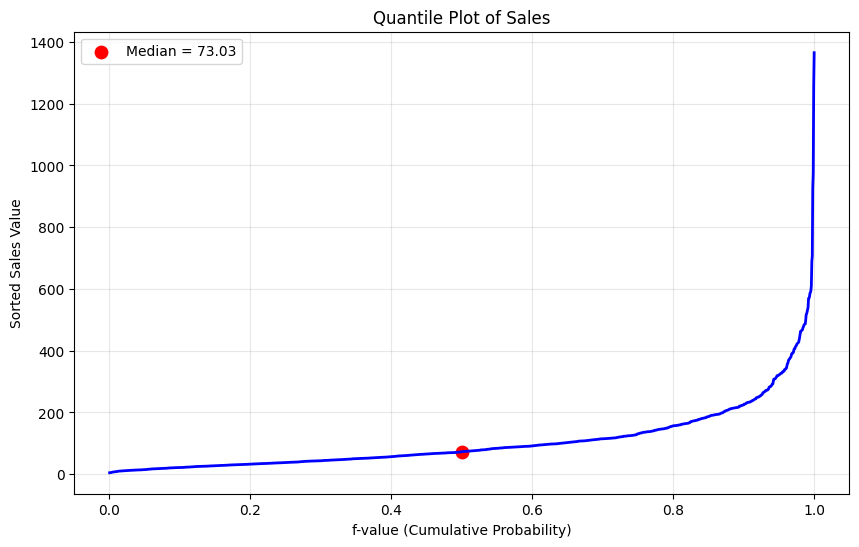

In [ ]:
# ==========================================
# Q4: Quantile Plot of Sales
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("synthetic_superstore.csv")

# ----------------------------------
# Sort Sales Values
# ----------------------------------
sales_sorted = np.sort(df["Sales"])

# Compute f-values (cumulative probability)
f_values = np.arange(1, len(sales_sorted) + 1) / len(sales_sorted)

# ----------------------------------
# Median Sales (f = 0.5)
# ----------------------------------
median_sales = df["Sales"].median()

# ----------------------------------
# Percentage of Sales < 100
# ----------------------------------
percentage_below_100 = (df["Sales"] < 100).mean() * 100

# ----------------------------------
# Print Results
# ----------------------------------
print("=" * 50)
print(f"Median Sales (f = 0.5): {median_sales:.2f}")
print(f"Percentage of Transactions with Sales < $100: {percentage_below_100:.2f}%")
print("=" * 50)

# ----------------------------------
# Quantile Plot
# ----------------------------------
plt.figure(figsize=(10,6))

plt.plot(
    f_values,
    sales_sorted,
    color="blue",
    linewidth=2
)

# Mark the median
plt.scatter(
    0.5,
    median_sales,
    color="red",
    s=80,
    label=f"Median = {median_sales:.2f}"
)

plt.xlabel("f-value (Cumulative Probability)")
plt.ylabel("Sorted Sales Value")
plt.title("Quantile Plot of Sales")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

Median Profit (East): 13.03
Median Profit (West): 20.96

West region has a higher median profit by approximately 7.93.


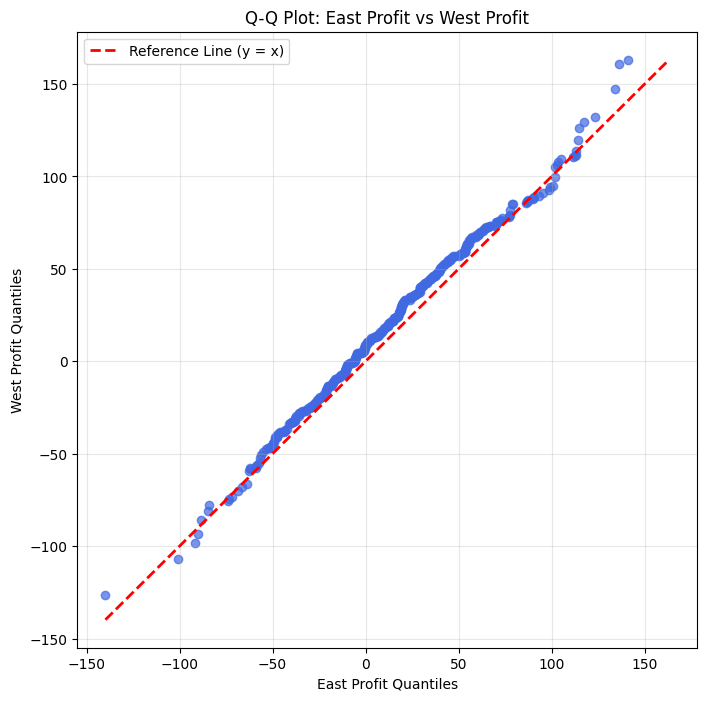

In [ ]:
# ==========================================
# Q5: Q-Q Plot (East vs West Profit)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("synthetic_superstore.csv")

# ----------------------------------
# Extract Profit for East and West
# ----------------------------------
east_profit = np.sort(df[df["Region"] == "East"]["Profit"])
west_profit = np.sort(df[df["Region"] == "West"]["Profit"])

# ----------------------------------
# Compute Common Quantiles
# ----------------------------------
n = min(len(east_profit), len(west_profit))

quantiles = np.linspace(0, 1, n)

east_q = np.quantile(east_profit, quantiles)
west_q = np.quantile(west_profit, quantiles)

# ----------------------------------
# Median Profits
# ----------------------------------
east_median = np.median(east_profit)
west_median = np.median(west_profit)

difference = west_median - east_median

# ----------------------------------
# Print Results
# ----------------------------------
print("=" * 55)
print(f"Median Profit (East): {east_median:.2f}")
print(f"Median Profit (West): {west_median:.2f}")

if difference > 0:
    print(f"\nWest region has a higher median profit by approximately {difference:.2f}.")
elif difference < 0:
    print(f"\nEast region has a higher median profit by approximately {abs(difference):.2f}.")
else:
    print("\nBoth regions have the same median profit.")

print("=" * 55)

# ----------------------------------
# Q-Q Plot
# ----------------------------------
plt.figure(figsize=(8,8))

plt.scatter(
    east_q,
    west_q,
    color="royalblue",
    alpha=0.7
)

# Reference line (y = x)
min_val = min(east_q.min(), west_q.min())
max_val = max(east_q.max(), west_q.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Reference Line (y = x)"
)

plt.title("Q-Q Plot: East Profit vs West Profit")
plt.xlabel("East Profit Quantiles")
plt.ylabel("West Profit Quantiles")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Pearson Correlation Coefficient = -0.280
Relationship: Negative Correlation


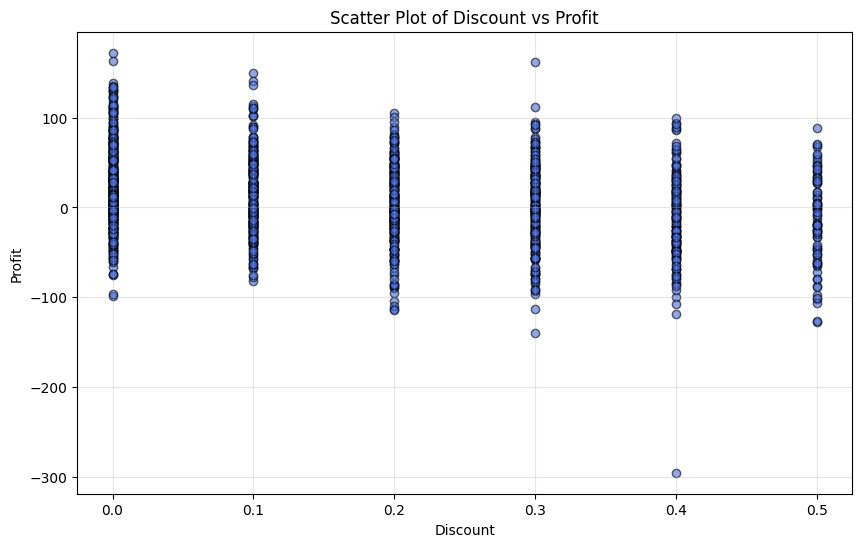

In [ ]:
# ==========================================
# Q6: Scatter Plot & Pearson Correlation
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("synthetic_superstore.csv")

# ----------------------------------
# Compute Pearson Correlation
# ----------------------------------
correlation = df["Discount"].corr(df["Profit"])

print("=" * 50)
print(f"Pearson Correlation Coefficient = {correlation:.3f}")

if correlation > 0:
    print("Relationship: Positive Correlation")
elif correlation < 0:
    print("Relationship: Negative Correlation")
else:
    print("Relationship: No Correlation")
print("=" * 50)

# ----------------------------------
# Scatter Plot
# ----------------------------------
plt.figure(figsize=(10,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    color="royalblue",
    alpha=0.6,
    edgecolors="black"
)

plt.title("Scatter Plot of Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(alpha=0.3)

plt.show()

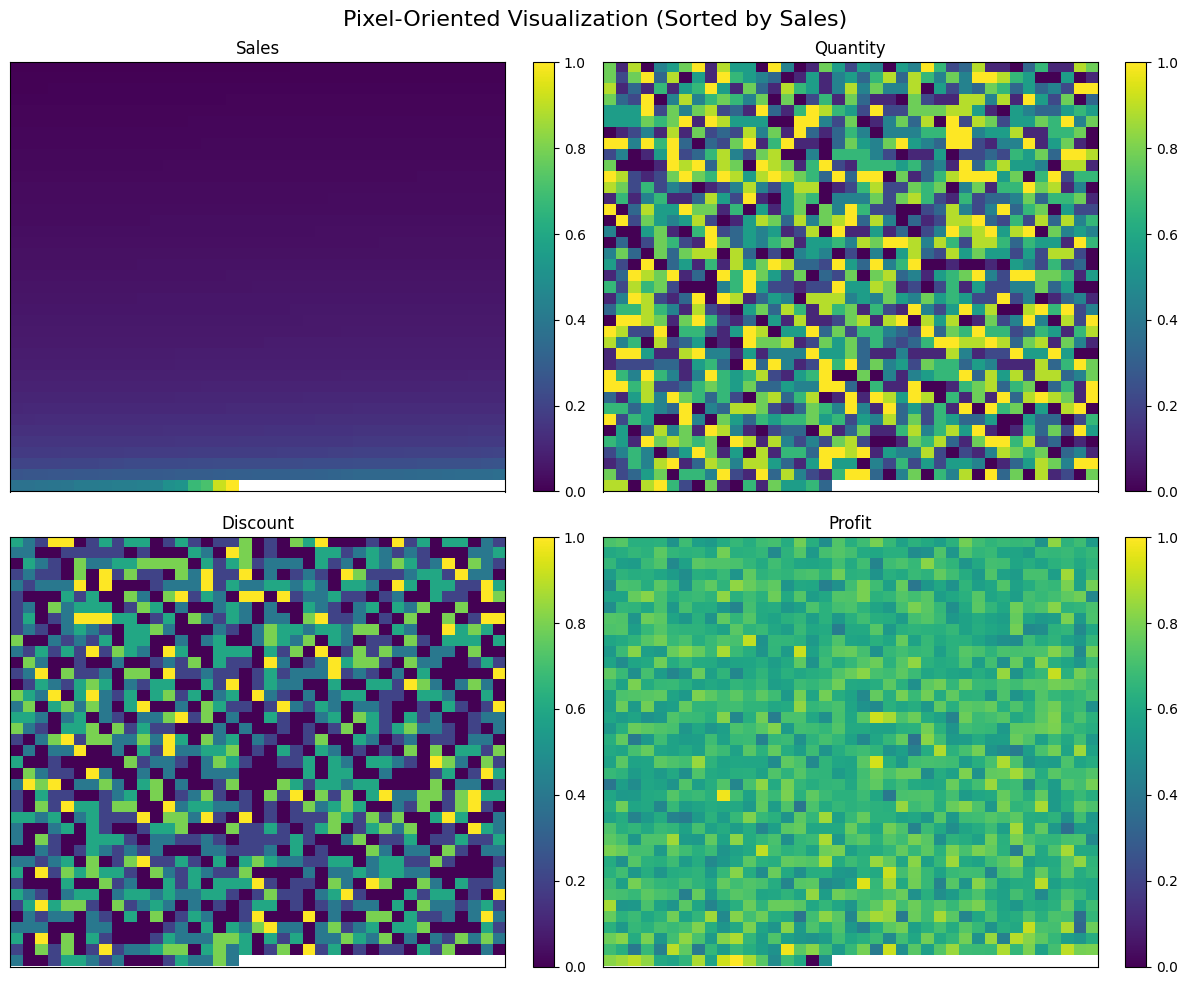

In [ ]:
# ==========================================
# Q7: Pixel-Oriented Visualization
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv("synthetic_superstore.csv")

# ----------------------------------
# Select Numeric Attributes
# ----------------------------------
attributes = ["Sales", "Quantity", "Discount", "Profit"]

# Sort records by Sales
df_sorted = df.sort_values(by="Sales").reset_index(drop=True)

# Normalize values to range [0,1]
scaler = MinMaxScaler()
normalized = scaler.fit_transform(df_sorted[attributes])

# ----------------------------------
# Reshape into Image
# ----------------------------------
n = len(df_sorted)

# Make nearly square image
cols = int(np.ceil(np.sqrt(n)))
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(2, 2, figsize=(12,10))

axes = axes.flatten()

for i, attr in enumerate(attributes):

    values = normalized[:, i]

    # Padding if necessary
    padded = np.pad(
        values,
        (0, rows * cols - n),
        mode='constant',
        constant_values=np.nan
    )

    image = padded.reshape(rows, cols)

    im = axes[i].imshow(
        image,
        cmap="viridis",
        aspect="auto"
    )

    axes[i].set_title(attr)
    axes[i].set_xticks([])
    axes[i].set_yticks([])

    plt.colorbar(im, ax=axes[i], fraction=0.046)

plt.suptitle("Pixel-Oriented Visualization (Sorted by Sales)", fontsize=16)

plt.tight_layout()
plt.show()

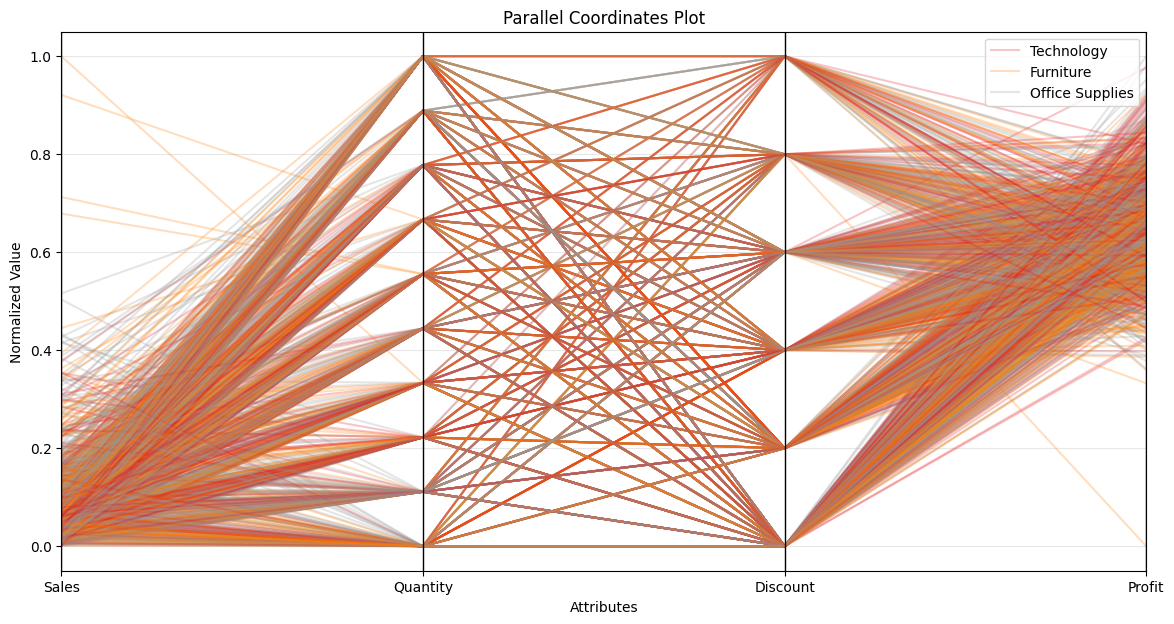

In [ ]:
# ==========================================
# Q8: Parallel Coordinates Plot
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv("synthetic_superstore.csv")

# ----------------------------------
# Select Required Columns
# ----------------------------------
data = df[["Sales", "Quantity", "Discount", "Profit", "Category"]].copy()

# ----------------------------------
# Normalize Numeric Columns
# ----------------------------------
scaler = MinMaxScaler()

numeric_cols = ["Sales", "Quantity", "Discount", "Profit"]

data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

# ----------------------------------
# Plot Parallel Coordinates
# ----------------------------------
plt.figure(figsize=(14,7))

parallel_coordinates(
    data,
    class_column="Category",
    colormap="Set1",
    alpha=0.25
)

plt.title("Parallel Coordinates Plot")
plt.xlabel("Attributes")
plt.ylabel("Normalized Value")
plt.grid(alpha=0.3)

plt.show()

Average Values


,Sales,Quantity,Discount,Profit
Sub_Category,,,,
Accessories,84.215333,5.816667,0.193333,27.263000
Appliances,123.194352,5.527778,0.165741,22.231852
Art,96.234719,5.696629,0.165169,11.022809
Binders,97.141368,5.684211,0.170526,10.024316
Bookcases,118.453016,5.579365,0.176190,3.380714
Chairs,130.886186,5.123711,0.191753,-0.359588
Copiers,80.820952,5.396825,0.142857,18.179683
Envelopes,110.201619,5.485714,0.170476,10.955333
Fasteners,110.333400,5.270000,0.201000,0.541200


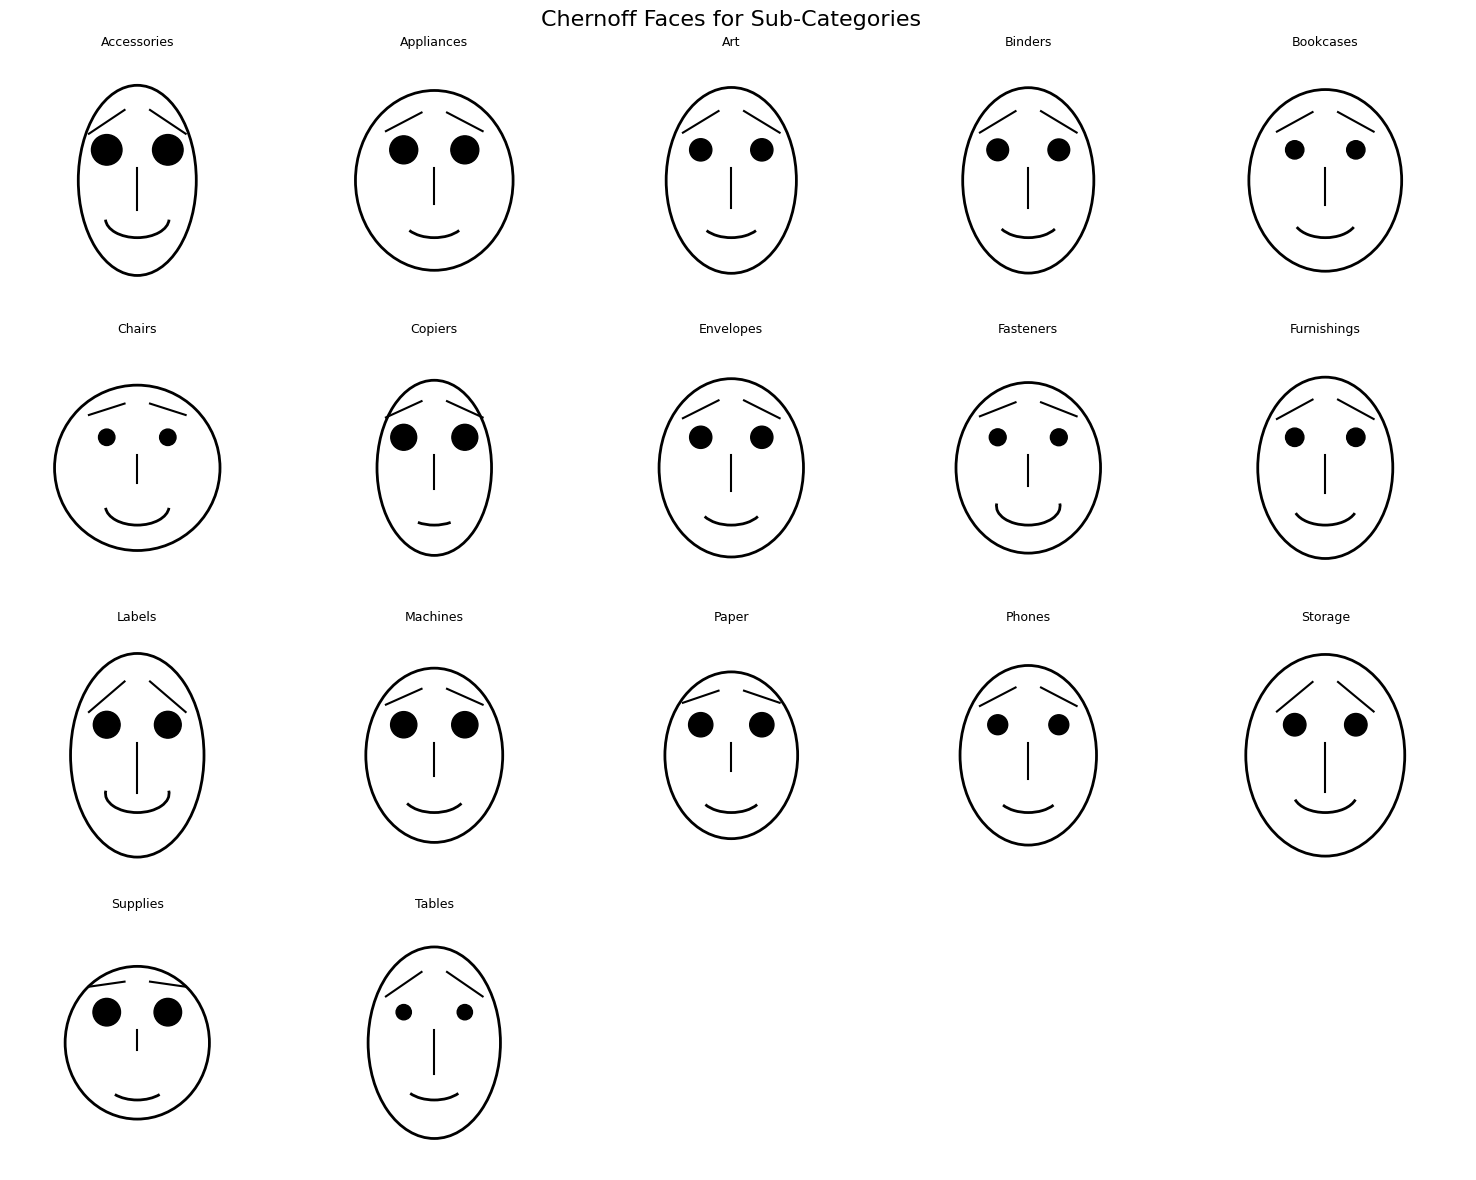

Most Similar Sub-Categories:
Art & Binders

Most Different Sub-Category:
Chairs


In [ ]:
# ==========================================
# Q9: Chernoff Faces (No External Libraries)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Ellipse, Arc
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import pdist, squareform

# Load dataset
df = pd.read_csv("synthetic_superstore.csv")

# ----------------------------------
# Aggregate by Sub_Category
# ----------------------------------
grouped = df.groupby("Sub_Category")[[
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]].mean()

print("Average Values")
display(grouped)

# ----------------------------------
# Normalize values
# ----------------------------------
scaler = MinMaxScaler()

normalized = pd.DataFrame(
    scaler.fit_transform(grouped),
    columns=grouped.columns,
    index=grouped.index
)

# ----------------------------------
# Function to draw one Chernoff face
# ----------------------------------
def draw_face(ax, values, title):

    sales, quantity, discount, profit = values

    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_aspect('equal')
    ax.axis('off')

    # Face
    face = Ellipse(
        (0.5,0.5),
        0.45 + sales*0.20,
        0.60 + quantity*0.20,
        fill=False,
        linewidth=2
    )
    ax.add_patch(face)

    # Eyes
    eye_size = 0.03 + profit*0.03

    ax.add_patch(Circle((0.38,0.62), eye_size, color="black"))
    ax.add_patch(Circle((0.62,0.62), eye_size, color="black"))

    # Nose
    nose_length = 0.08 + quantity*0.12

    ax.plot(
        [0.5,0.5],
        [0.55,0.55-nose_length],
        color="black"
    )

    # Mouth
    curvature = (discount-0.5)*0.5

    mouth = Arc(
        (0.5,0.35),
        0.25,
        0.15,
        theta1=200-curvature*100,
        theta2=340+curvature*100,
        linewidth=2
    )

    ax.add_patch(mouth)

    # Eyebrows
    angle = quantity*0.05

    ax.plot([0.31,0.45],[0.72-angle,0.74+angle],color="black")
    ax.plot([0.55,0.69],[0.74+angle,0.72-angle],color="black")

    ax.set_title(title, fontsize=9)


# ----------------------------------
# Plot All Faces
# ----------------------------------
fig, axes = plt.subplots(4,5,figsize=(15,12))

axes = axes.flatten()

for ax, (name,row) in zip(axes, normalized.iterrows()):
    draw_face(ax, row.values, name)

# Hide empty subplot
for ax in axes[len(normalized):]:
    ax.axis('off')

plt.suptitle("Chernoff Faces for Sub-Categories", fontsize=16)
plt.tight_layout()
plt.show()

# ----------------------------------
# Similarity Analysis
# ----------------------------------
dist = squareform(pdist(grouped))

dist_df = pd.DataFrame(
    dist,
    index=grouped.index,
    columns=grouped.index
)

np.fill_diagonal(dist_df.values, np.inf)

similar = dist_df.stack().idxmin()

avg_dist = dist_df.replace(np.inf,np.nan).mean(axis=1)

different = avg_dist.idxmax()

print("="*60)
print("Most Similar Sub-Categories:")
print(similar[0], "&", similar[1])

print("\nMost Different Sub-Category:")
print(different)
print("="*60)

Average Profit Matrix
Category  Furniture  Office Supplies  Technology
Region                                          
Central   -2.156200         3.264012   23.599882
East       7.026967        16.346032   14.393034
South    -11.929515        -2.903060   10.631798
West       9.566121        23.414455   24.470600

Lowest Average Profit
Region   : South
Category : Furniture
Average Profit : -11.93


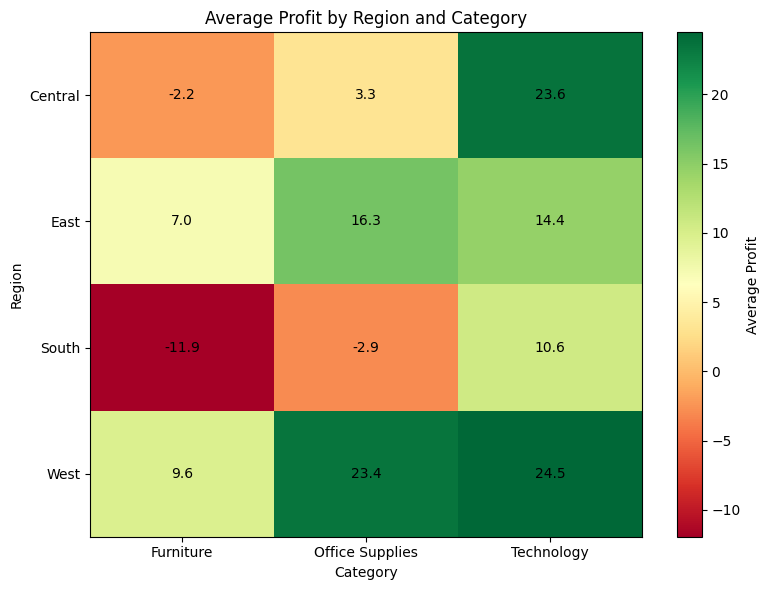

In [ ]:
# ==========================================
# Q10: Dimensional Stacking (Heatmap)
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("synthetic_superstore.csv")

# ----------------------------------
# Average Profit by Region & Category
# ----------------------------------
profit_matrix = df.pivot_table(
    values="Profit",
    index="Region",
    columns="Category",
    aggfunc="mean"
)

print("Average Profit Matrix")
print(profit_matrix)
print()

# ----------------------------------
# Find Lowest Average Profit
# ----------------------------------
lowest_value = profit_matrix.min().min()

lowest_location = profit_matrix.stack().idxmin()

print("=" * 60)
print("Lowest Average Profit")
print(f"Region   : {lowest_location[0]}")
print(f"Category : {lowest_location[1]}")
print(f"Average Profit : {lowest_value:.2f}")
print("=" * 60)

# ----------------------------------
# Heatmap
# ----------------------------------
plt.figure(figsize=(8,6))

plt.imshow(
    profit_matrix,
    cmap="RdYlGn",
    aspect="auto"
)

plt.colorbar(label="Average Profit")

plt.xticks(
    range(len(profit_matrix.columns)),
    profit_matrix.columns
)

plt.yticks(
    range(len(profit_matrix.index)),
    profit_matrix.index
)

# Write values inside cells
for i in range(len(profit_matrix.index)):
    for j in range(len(profit_matrix.columns)):
        plt.text(
            j,
            i,
            f"{profit_matrix.iloc[i,j]:.1f}",
            ha="center",
            va="center",
            color="black",
            fontsize=10
        )

plt.title("Average Profit by Region and Category")
plt.xlabel("Category")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

Total Sales by Sub_Category
Sub_Category
Bookcases      14925.08
Appliances     13304.99
Chairs         12695.96
Storage        12574.28
Envelopes      11571.17
Furnishings    11511.56
Fasteners      11033.34
Tables         10225.32
Paper           9675.37
Binders         9228.43
Art             8564.89
Phones          7064.06
Supplies        6714.00
Labels          6661.30
Copiers         5091.72
Accessories     5052.92
Machines        4420.77
Name: Sales, dtype: float64

Top 3 Sub-Categories by Total Sales
Sub_Category
Bookcases     14925.08
Appliances    13304.99
Chairs        12695.96
Name: Sales, dtype: float64

Combined Contribution = 25.53%


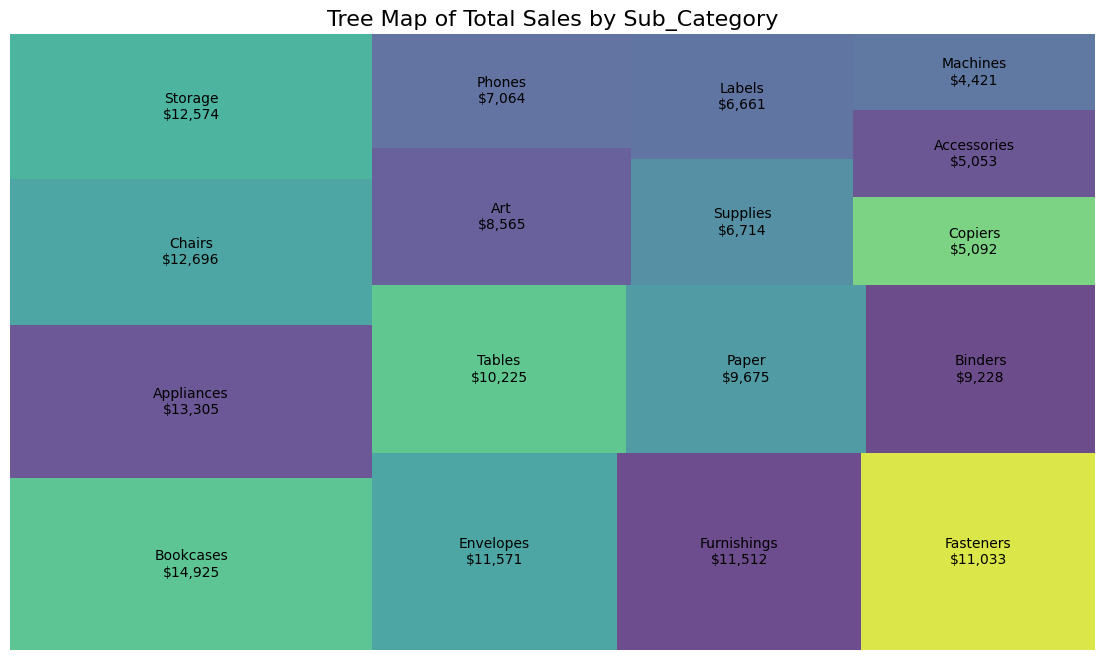

In [ ]:
# ==========================================
# Q11: Tree Map of Total Sales by Sub_Category
# ==========================================

# Install squarify (Run only once)
!pip install squarify -q

import pandas as pd
import matplotlib.pyplot as plt
import squarify

# ----------------------------------
# Load Dataset
# ----------------------------------
df = pd.read_csv("synthetic_superstore.csv")

# ----------------------------------
# Total Sales by Sub_Category
# ----------------------------------
sales = (
    df.groupby("Sub_Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print("Total Sales by Sub_Category")
print(sales)
print()

# ----------------------------------
# Top 3 Sub-Categories
# ----------------------------------
top3 = sales.head(3)

total_sales = sales.sum()

percentage = top3.sum() / total_sales * 100

print("=" * 60)
print("Top 3 Sub-Categories by Total Sales")
print(top3)
print()
print(f"Combined Contribution = {percentage:.2f}%")
print("=" * 60)

# ----------------------------------
# Tree Map
# ----------------------------------
plt.figure(figsize=(14,8))

squarify.plot(
    sizes=sales.values,
    label=[f"{name}\n${value:,.0f}" for name, value in sales.items()],
    alpha=0.8
)

plt.title("Tree Map of Total Sales by Sub_Category", fontsize=16)
plt.axis("off")

plt.show()